# Poisson equation with method of manufactured solutions

$$
\mathbb{S}_u
\begin{cases}
\Omega = [0, 1] \times [0, 1] \\
u_{\text{e}}(x,y)=\cos(2\pi x)\cos(2\pi y) \\
\end{cases}
$$

In [1]:
from typing import Callable
import numpy as np
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from ufl.core.expr import Expr
from ufl import SpatialCoordinate, div, grad, cos
from dolfinx.fem import FunctionSpace

from lucifex.mesh import rectangle_mesh, mesh_boundary
from lucifex.fem import Function
from lucifex.solver import bvp, BoundaryConditions, l_norm, L_norm, BoundaryValueProblem
from lucifex.plt import plot_line, save_figure
from lucifex.utils.py_utils import nested_dict
from lucifex.utils.fenicsx_utils import set_function_interpolate, set_function
from lucifex.pde.poisson import poisson

def create_solver(
    Lx: float,
    Nx: int,
    exact_solution: Callable[[SpatialCoordinate], Expr],
    cell: str,
    family: str,
    degree: int,
) -> BoundaryValueProblem:
    Lx = 1.0
    mesh = rectangle_mesh(Lx, Lx, Nx, Nx, cell)
    boundary = mesh_boundary(
        mesh, 
        {
            "left": lambda x: x[0],
            "right": lambda x: x[0] - Lx,
            "lower": lambda x: x[1],
            "upper": lambda x: x[1] - Lx,
        },
        complete=True,
    )
    fs = FunctionSpace(mesh, (family, degree))
    x = SpatialCoordinate(mesh)
    ue = exact_solution(x)
    bcs = BoundaryConditions(
        ("dirichlet", boundary.union, ue),
    )
    f = div(grad(ue))
    u = Function(fs, name='u')
    return bvp(poisson, bcs)(u, f)

def compute_norms(
    u: Function,
    exact_solution: Callable[[SpatialCoordinate], Expr],
    degree_raise: int = 0,
    **dx_metadata,
) -> tuple[float, float, float, float]:
    if degree_raise:
        family = u.function_space.ufl_element().family()
        degree = u.function_space.ufl_element().degree()
        fs = FunctionSpace(u.function_space.mesh, (family, degree + degree_raise))
    else:
        fs = u.function_space
    
    x = SpatialCoordinate(u.function_space.mesh)
    ue = exact_solution(x)
    u_func = Function(fs)
    u_func.interpolate(u)
    ue_func = Function(fs)
    set_function_interpolate(ue_func, ue)
    e_func = Function(fs)
    set_function(e_func, ue_func.x.array - u_func.x.array, ':')

    L2_norm_expr = L_norm('dx', **dx_metadata)(ue - u_func, 2.0)
    L2_norm_func = L_norm('dx', **dx_metadata)(e_func, 2.0)
    l2_norm = l_norm(e_func, 2.0)
    linf_norm = l_norm(e_func, 'inf')

    return np.sqrt(L2_norm_expr), np.sqrt(L2_norm_func), l2_norm, linf_norm


Lx = 1.0
exact_solution = lambda x: cos(2 * np.pi * x[0]) * cos(2 * np.pi * x[1])

Nx_opts = (10, 50, 100, 150)
degree_raise_opts = (0, 3)
solutions = nested_dict((str, int, float, Function))

for Nx in Nx_opts:
    h = Lx / Nx
    for deg_raise in degree_raise_opts:
        u_solver = create_solver(Lx, Nx, exact_solution, 'right', 'P', 1)
        u_solver.solve()
        u = u_solver.solution
        L2_norm_expr, L2_norm_func, l2_norm, linf_norm = compute_norms(u, exact_solution, deg_raise)
        solutions['L2_Expr'][deg_raise][h] = L2_norm_expr
        solutions['L2_Function'][deg_raise][h] = L2_norm_func
        solutions['l2'][deg_raise][h] = l2_norm
        solutions['linf'][deg_raise][h] = linf_norm



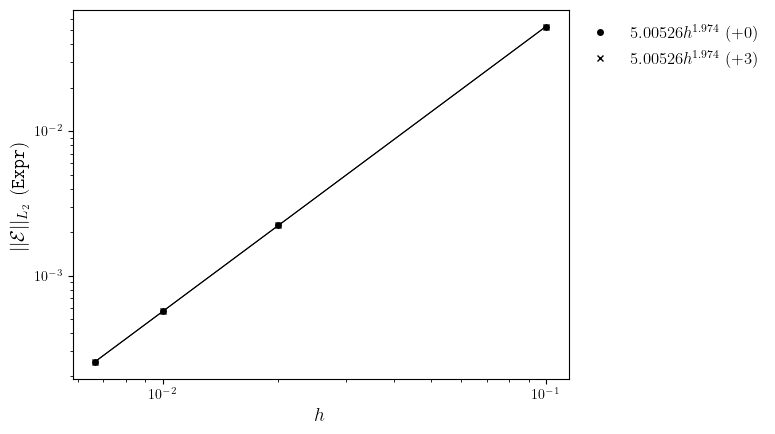

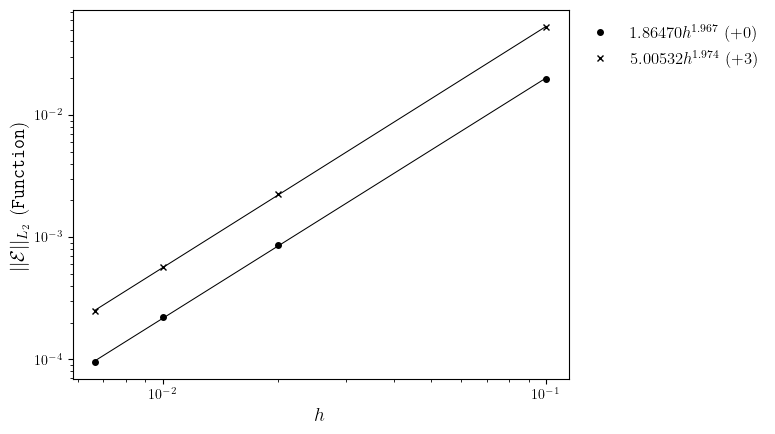

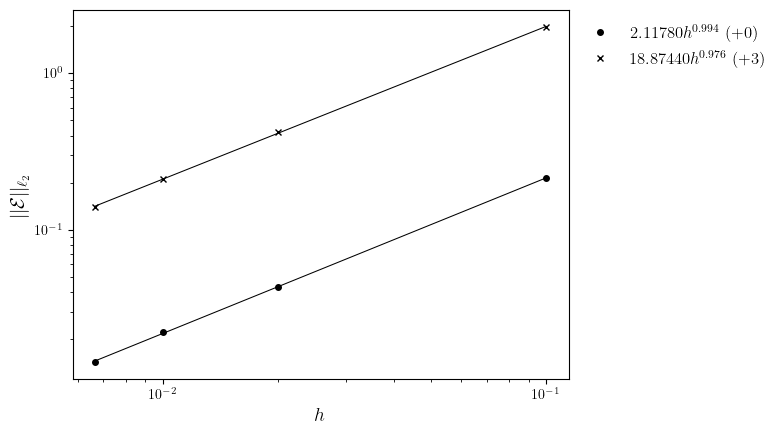

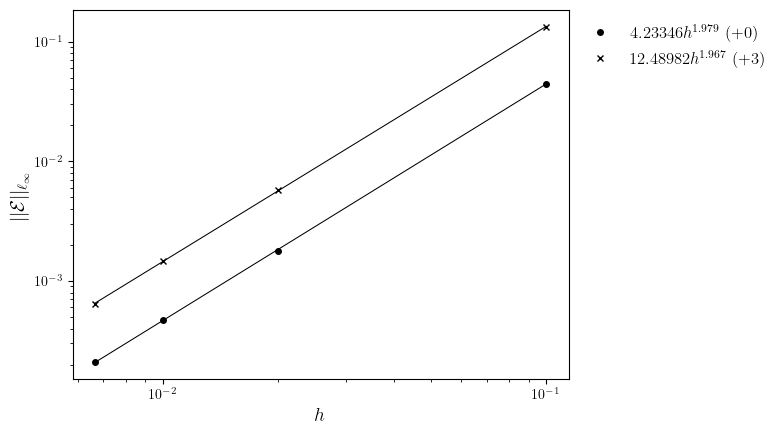

In [3]:
norm_type_tex = {
    'L2_Expr': '_{L_2}~(\\texttt{Expr})',
    'L2_Function': '_{L_2}~(\\texttt{Function})',
    'l2': '_{\ell_2}',
    'linf': '_{\ell_\infty}'
}

for norm_type, subdict in solutions.items():
    lines, lobfs, legend_labels = [], [], []
    for deg_raise, h_u_dict in subdict.items():
        h_values = list(h_u_dict.keys())
        e_values = list(h_u_dict.values())
        lines.append((h_values, e_values))
        gradient, intercept = np.polyfit(np.log(h_values), np.log(e_values), 1)
        legend_labels.append(
            f'${np.exp(intercept):.5f}h^{{{gradient:.3f}}}$ (+{deg_raise})'
        )
        lobf = np.exp(intercept) * h_values ** gradient
        lobfs.append((h_values, lobf))

    fig, ax = plot_line(
        lines,
        legend_labels=legend_labels,
        cyc='marker',
        linestyle='',
        x_label=f'$h$', 
        y_label=f'$||\mathcal{{E}}||{norm_type_tex[norm_type]}$', 
    )
    plot_line(fig, ax, lobfs, color='black', linestyle='solid', linewidth=0.75)
    ax.set_xscale('log')
    ax.set_yscale('log')
    save_figure(f'e(h)_{norm_type}', thumbnail=(norm_type == 'L2_Function'))(fig)
